In [1]:
from datasets import load_from_disk
from transformers import AutoTokenizer, RobertaForSequenceClassification

In [3]:
dataset = load_from_disk("../gold-dataset")
dataset = dataset["train"]

# filter out any cases where 'words' or 'numeric' is None
dataset = dataset.filter(lambda x: x["words"] is not None and x["numeric"] is not None)
dataset = dataset.map(lambda x: {"words": x["words"].lower(), "numeric": x["numeric"]})

dataset

Dataset({
    features: ['checkDetectionResultId', 'numeric', 'words', 'numeric_confidence', 'words_confidence'],
    num_rows: 3452
})

In [4]:
model_path = "../results/distilroberta-base-5-epoch-128-batch-2e-5-lr-max-logging"

model = RobertaForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

In [5]:
def infer(examples):
    inputs = tokenizer(examples['words'], examples['numeric'], padding="max_length", truncation=True, return_tensors="pt")
    outputs = model(**inputs)

    logits = outputs.logits
    predicted_classes_idx = logits.argmax(dim=-1).tolist()
    predicted_classes = [model.config.id2label[idx] for idx in predicted_classes_idx]

    return {"predicted_class": predicted_classes, "logits": logits.tolist()}

In [6]:
results = dataset.map(infer, batched=True, batch_size=64)

Map:   0%|          | 0/3452 [00:00<?, ? examples/s]

In [7]:
df = results.to_pandas()

df.head()

,checkDetectionResultId,numeric,words,numeric_confidence,words_confidence,predicted_class,logits
0,779193b8-e8b4-4a4c-ae94-92c8f6db4d64,240.00,two hundred forty and 00/100 dollars,99.0,94.0,LABEL_1,"[-3.4023892879486084, 3.7790415287017822]"
1,93f0e924-87be-4861-b044-4f91179ca841,126.03,one hundred twenty six dollars and three cents,99.0,96.0,LABEL_1,"[-3.6893699169158936, 4.003620624542236]"
2,e7b80881-4116-428f-98bc-d55d1ab90cd6,200.00,two hundred and 00/100,99.0,99.0,LABEL_1,"[-3.2078258991241455, 3.509220838546753]"
3,02753fd9-250d-4fb0-bd15-16da6bf1b9e1,382.12,three hundred eighty two and 12/100 dollars,98.0,97.0,LABEL_1,"[-3.0330374240875244, 3.368556499481201]"
4,6fc1f38e-657a-4744-9aba-172ebede380e,2.00,two dollars and no cents,100.0,98.0,LABEL_1,"[-3.4889416694641113, 3.8635737895965576]"


<Axes: >

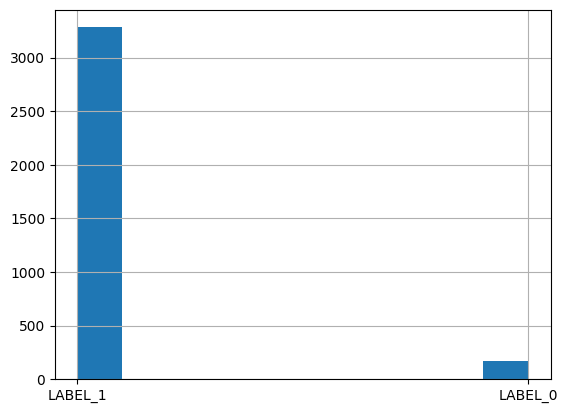

In [8]:
df['predicted_class'].hist()

In [10]:
mismatches = df[df['predicted_class'] != 'LABEL_1']
mismatches = mismatches[['words', 'numeric']]

mismatches.head()

,words,numeric
7,three hundred twenty dollars & 42/100,32042.00
55,**nine hundred and xx/100 dollar**,900.00
60,three hundred seventy - four dollars and twent...,374.25
64,seven hundred ninety-two & no/100,40000.00
77,five thousand eight hundred thirty four,5834.95
